In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
import os
import seaborn as sns

from tp7.tp7 import Tape7
from srfs.srfs import SRFS
from matt_code.convert_tp7 import load_all_runs_from_tp7
import scipy.integrate as integrate
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, explained_variance_score, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.tree import export_text, plot_tree

import warnings
warnings.filterwarnings('ignore')
def modtran_data_files(path: str) -> list:
    files = [path + "/" + file for file in os.listdir(path) if file.endswith(".tp7")]
    return files

a00_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA00")
a41_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA41")
a60_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA60")
a75_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA75")
a85_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA85")

srf = SRFS("./data/libera_srfs_20241017.csv")
tot_wvln = srf.srf_vals['wavelength [um]']
sw_srf = srf.srf_vals[' sw srf']
lw_srf = srf.srf_vals[' lw srf']
# tot_wvln = srf.srf_vals['wavelength_um']
# sw_srf = srf.srf_vals['sw_srf']
# lw_srf = srf.srf_vals['lw_srf']

viirs_rads_indxs = {'M1': [1469, 1701],
             'M2': [1648, 1849],
             'M3': [1873, 2039],
             'M4': [2131, 2260],
             'I1': [2231, 2601],
             'M5': [2467, 2559],
             'DNB': [667, 3090],
             'M6': [2621, 2696],
             'I2': [2790, 2893],
             'M7': [2790, 2893],
             'M8': [3181, 3206],
             'M9': [3264, 3284],
             'I3': [3355, 3401],
             'M10': [3355, 3401],
             'M11': [3546, 3565],
             'I4': [3703, 3757],
             'M12': [3716, 3742],
             'M13': [3744, 3762],
             'M14': [3879, 3887],
             'M15': [3898, 3914],
             'I5': [3896, 3925],
             'M16': [3910, 3922]}

viirs_band_ranges = {
    "I1": "I1 0.60 - 0.68 μm",
    "I2": "I2 0.85 - 0.88 μm",
    "I3": "I3 1.58 - 1.64 μm",
    "I4": "I4 3.55 - 3.93 μm",
    "I5": "I5 10.5 - 12.4 μm",
    "M1": "M1 0.402 - 0.422 μm",
    "M2": "M2 0.436 - 0.454 μm",
    "M3": "M3 0.478 - 0.488 μm",
    "M4": "M4 0.545 - 0.565 μm",
    "M5": "M5 0.662 - 0.682 μm",
    "M6": "M6 0.739 - 0.754 μm",
    "M7": "M7 0.846 - 0.885 μm",
    "M8": "M8 1.23 - 1.25 μm",
    "M9": "M9 1.371 - 1.386 μm",
    "M10": "M10 1.58 - 1.64 μm",
    "M11": "M11 2.23 - 2.28 μm",
    "M12": "M11 3.61 - 3.79 μm",
    "M13": "M13 3.97 - 4.13 μm",
    "M14": "M14 8.4 - 8.7 μm",
    "M15": "M15 10.26 - 11.26 μm",
    "M16": "M16 11.54 - 12.49 μm",
    "DNB": "DNB 0.50 - 0.90 μm"
}

def rename_bands(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(columns=viirs_band_ranges)
def plot_radiance(rads, title, runnum, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    ax.plot(rads[runnum, 0, :], rads[runnum, s_or_l, :] * 1e6, 'r-', label='Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 2:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)
        

def plot_integrated_radiance(rads, title, idx, wvs, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    ax.plot(wvs, rads[idx, :], 'r-', label='Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 1:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)


y_lim_map = {
    "Snow": [[1.75e-6, 4], [1e-5, 100]],
    "Cloudy Ocean": [[2.25e-6, 5], [1e-5, 100]],
    "Land": [[600, 3], [10, 50]],
    "Clear Ocean": [[7e-7, 3], [1.75e-5, 100]],
    "Deep Convective Cloud": [[500, 3], [2.5, 80]]
}

def plot_sza(sza_dict: dict):
    fig, axes = plt.subplots(5, 1, figsize=(18, 50))

    for i, (key, tp7) in enumerate(sza_dict.items()):

        wavelength = tp7.rads[0, 0, :]

        print(key)
        ax_sw = axes[i]
        shortwave = tp7.rads[-1, 1, :]
        interp_shortwave_filt = np.interp(x=wavelength, xp=tot_wvln, fp=sw_srf)
        shortwave_filt = interp_shortwave_filt * shortwave

        ax_sw.plot(wavelength, shortwave_filt, 'r-', label='Filtered')
        ax_sw.plot(wavelength, shortwave, 'b-', label='Unfiltered')
        # ax_sw.set_xlim(0, y_lim_map[key][0][1])
        # ax_sw.set_ylim(0, y_lim_map[key][0][0])
        ax_sw.set_xlim(0, y_lim_map["Land"][0][1])
        ax_sw.set_ylim(0, y_lim_map["Land"][0][0])

        ax_sw.legend(prop={"size": 10})
        ax_sw.set_title(f'Shortwave: {key}')
        ax_sw.set_ylabel('Radiance Wm$^{-2}$µm$^{-1}$sr$^{-1}$')
        ax_sw.set_xlabel('Wavelength µm')
        ax_sw.grid(True)


        # ax_lw = axes[i, 1]
        # longwave = tp7.rads[-1, 2, :]
        # longwave_filt = np.interp(x=wavelength, xp=tot_wvln, fp=lw_srf)
        # longwave_filt = longwave_filt * shortwave
        # ax_lw.plot(wavelength, longwave, longwave_filt, 'b-', label='Longwave')
        # ax_lw.set_xlim(5, y_lim_map[key][1][1])
        # ax_lw.set_ylim(0, y_lim_map[key][1][0])
        #
        # ax_lw.legend(prop={"size": 10})
        # ax_lw.set_title(f'Longwave: {key}')
        # ax_lw.set_ylabel('Radiance Wm$^{-2}$µm$^{-1}$sr$^{-1}$')
        # ax_lw.set_xlabel('Wavelength µm')
        # ax_lw.grid(True)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4)
    plt.show()


viirs_rads_indxs = {'M1': [1469, 1701],
             'M2': [1648, 1849],
             'M3': [1873, 2039],
             'M4': [2131, 2260],
             'I1': [2231, 2601],
             'M5': [2467, 2559],
             'DNB': [667, 3090],
             'M6': [2621, 2696],
             'I2': [2790, 2893],
             'M7': [2790, 2893],
             'M8': [3181, 3206],
             'M9': [3264, 3284],
             'I3': [3355, 3401],
             'M10': [3355, 3401],
             'M11': [3546, 3565],
             'I4': [3703, 3757],
             'M12': [3716, 3742],
             'M13': [3744, 3762],
             'M14': [3879, 3887],
             'M15': [3898, 3914],
             'I5': [3896, 3925],
             'M16': [3910, 3922]}

def viirs_band_integration(tp7_data: Tape7, rad_indxs: dict):
    for idx, run in enumerate(tp7_data.rads):
        for band, rng in rad_indxs.items():
            y_vals = run[1][rng[0]: rng[1] + 1]
            x_vals = run[0][rng[0]: rng[1] + 1]
            integrated = integrate.simpson(y=y_vals, x=x_vals)
            tp7_data.describer_df.loc[idx, band] = integrated


a00_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a00_files]
titles = [file.title for file in a00_data]
a00 = {title: file for title, file in zip(titles, a00_data)}

a41_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a41_files]
titles = [file.title for file in a41_data]
a41 = {title: file for title, file in zip(titles, a41_data)}

a60_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a60_files]
titles = [file.title for file in a60_data]
a60 = {title: file for title, file in zip(titles, a60_data)}

a75_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a75_files]
titles = [file.title for file in a75_data]
a75 = {title: file for title, file in zip(titles, a75_data)}

a85_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a85_files]
titles = [file.title for file in a85_data]
a85 = {title: file for title, file in zip(titles, a85_data)}


snow_data = [a00["Snow"], a41["Snow"], a60["Snow"], a75["Snow"], a85["Snow"]]
dc_data = [a00["Deep Convective Cloud"], a41["Deep Convective Cloud"], a60["Deep Convective Cloud"],
           a75["Deep Convective Cloud"], a85["Deep Convective Cloud"]]
land_data = [a00["Land"], a41["Land"], a60["Land"], a75["Land"], a85["Land"]]
clear_data = [a00["Clear Ocean"], a41["Clear Ocean"], a60["Clear Ocean"], a75["Clear Ocean"], a85["Clear Ocean"]]
cloudy_data = [a00["Cloudy Ocean"], a41["Cloudy Ocean"], a60["Cloudy Ocean"], a75["Cloudy Ocean"], a85["Cloudy Ocean"]]
[viirs_band_integration(data, viirs_rads_indxs) for data in snow_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in dc_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in land_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in clear_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in cloudy_data]


snow_dfs = [file.describer_df for file in snow_data]
snow_dataset = pd.concat(snow_dfs, axis=0)
land_dfs = [file.describer_df for file in land_data]
dc_dfs = [file.describer_df for file in dc_data]
cloud_dfs = [file.describer_df for file in cloudy_data]
clear_dfs = [file.describer_df for file in clear_data]
land_dataset = pd.concat(land_dfs, axis=0)
dc_dataset = pd.concat(dc_dfs, axis=0)
cloud_dataset = pd.concat(cloud_dfs, axis=0)
clear_dataset = pd.concat(clear_dfs, axis=0)
all_dataset = pd.concat([snow_dataset, land_dataset, dc_dataset, cloud_dataset, clear_dataset])

def run_regression_model(dataset: pd.DataFrame, neurons=100, rf = True):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    # in the X dataset we want everything except the Unfiltered ground truth data and the run # and Scene
    X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)",]).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                               'Shortwave Filtered Rads (Integrated)',
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    print(X.columns, y.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

    if rf:
        base_model = RandomForestRegressor(n_estimators=neurons, random_state=42)
    else:
        base_model = LinearRegression()
    regression_model = MultiOutputRegressor(base_model)
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
    rmse = root_mean_squared_error(y_test, y_pred, multioutput='raw_values')
    mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Single MSE"] = mse
    ret["RMSE"] = rmse
    ret["MAE"] = mae
    ret["MAEP"] = mae_percentage

    tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    ret["Shortwave MSPE"] = (1.0 - (rmse[0] / tg_range_sw)) * 100

    tg_range_lw = max(y_test["Longwave Unfiltered Rads (Integrated)"]) - min(y_test["Longwave Unfiltered Rads (Integrated)"])
    ret["Longwave MSPE"] = (1.0 - (rmse[1] / tg_range_lw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    ret["CV RMSE"] = cv_scores
    ret["Model"] = regression_model
    ret["Predictions"] = y_pred
    ret["Y_True"] = y_test

    return ret



def run_shortwave_regression_model(dataset: pd.DataFrame, neurons=100, rf = True):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    # in the X dataset we want everything except the Unfiltered ground truth data and the run # and Scene
    X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)"]).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                               'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)",
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    print(X.columns, y.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

    regression_model = RandomForestRegressor(n_estimators=neurons, random_state=42)
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Single MSE"] = mse
    ret["RMSE"] = rmse
    ret["MAE"] = mae
    # ret["MAEP"] = mae_percentage

    tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    ret["CV RMSE"] = cv_scores

    return [ret, y_pred]


def estimator_testing(scene: str, dataset: pd.DataFrame):
    res = {}
    N = [10, 25, 50, 100, 125, 150, 200]
    tests = [run_regression_model(dataset, neurons=n) for n in N]
    for i in range(len(N)):
        del tests[i]["Model"]
        del tests[i]["Predictions"]
        del tests[i]["Y_True"]
        res[f"{scene}_{N[i]}"] = tests[i]

    return res


min_shortwave = min(all_dataset["Shortwave Filtered Rads (Integrated)"])
max_shortwave = max(all_dataset["Shortwave Filtered Rads (Integrated)"])
scaler = MinMaxScaler(feature_range=(min_shortwave, max_shortwave))
all_dataset["Scaled Shortwave Filtered"] = MinMaxScaler().fit_transform(all_dataset[["Shortwave Filtered Rads (Integrated)"]])
all_dataset["Scaled Shortwave Unfiltered"] = MinMaxScaler().fit_transform(all_dataset[['Shortwave Unfiltered Rads (Integrated)']])
all_dataset["Scaled Longwave Filtered"] = MinMaxScaler().fit_transform(all_dataset[["Longwave Filtered Rads (Integrated)"]])
all_dataset["Scaled Longwave Unfiltered"] = MinMaxScaler().fit_transform(all_dataset[['Longwave Unfiltered Rads (Integrated)']])
min(all_dataset["Scaled Shortwave Unfiltered"]), max(all_dataset["Scaled Shortwave Unfiltered"])


def add_noise_to_features(X: np.ndarray, noise_level: float, seed: int = 42):
    np.random.seed(seed)
    noise = np.random.normal(loc=0.0, scale=noise_level, size=X.shape)
    return X + noise


def run_shortwave_regression_model_scaled(dataset: pd.DataFrame, scaled: bool, rf: bool, v: bool, viirs_bands: bool, noised: bool, noise_level: float = 0.01, neurons: int = 100, tree_depth: int = 10):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    X, y = None, None

    columns_to_drop = ["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",
                      "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 
                      'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered', "Cloud",
                       'Scaled Shortwave Filtered',]

    # print(dataset.columns)
    
    if not viirs_bands:
        columns_to_drop.extend(['M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 
                              'I3', 'M10', 'M11', 'I4', 'M1', 'M2', 'M3', 'M4', 'I1'])

    if scaled:
        X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Filtered',
                                  'Shortwave Unfiltered Rads (Integrated)', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16',]).reset_index(drop=True)

    else:
        X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                   'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)

    params = {'bootstrap': True,
            'max_depth': 12,
            'max_features': None,
            'max_samples': 0.8,
            'min_samples_leaf': 2,
            'min_samples_split': 5,
            'n_estimators': 100}


    if rf:
        regression_model = RandomForestRegressor(**params)
    else:
        regression_model = LinearRegression()
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Mean_Absolute_Percentage_Error"] = mape
    ret["Root_Mean_Squared_Error"] = rmse
    ret["Mean_Absolute_Error"] = mae
    ret["Accuracy"] = 100 - mape
    # ret["MAEP"] = mae_percentage

    # tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    # ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(regression_model, X, y, cv=5, scoring="r2")
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["R_Squared"] = r2_score(y_test, y_pred)

    ret["Model"] = regression_model

    return [ret, y_pred, y_test]


def run_MLP(dataset: pd.DataFrame, scaled: bool, v: bool, noised: bool, noise_level: float = 0.01, neurons: tuple = (8, 4), max_iter: int = 500):

    ret = {}
    X, y = None, None
    if scaled:
        X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered',
                                  'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                                  'M1', 'M2', 'M3', 'M4', 'I1',]).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Filtered',
                                  'Shortwave Unfiltered Rads (Integrated)', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    else:
        X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",  "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Filtered', 'Scaled Shortwave Unfiltered',
                                  'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                                  'M1', 'M2', 'M3', 'M4', 'I1',]).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                   'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)


    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)

    MLP = MLPRegressor(
        # hidden_layer_sizes=(32, 16, 8), # best for scaled (8, 4)
        hidden_layer_sizes=neurons,
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size='auto',
        learning_rate='adaptive',
        max_iter=max_iter,
        random_state=42
    )

    MLP.fit(X_train, y_train)

    # Evaluate
    train_accuracy = MLP.score(X_train, y_train)
    test_accuracy = MLP.score(X_test, y_test)

    y_pred = MLP.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    cv_scores = cross_val_score(MLP, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(MLP, X, y, cv=5, scoring="r2")

    ret["Mean_Absolute_Error"] = mae
    ret["Train_Accuracy"] = train_accuracy
    ret["Test_Accuracy"] = test_accuracy
    ret["Mean_Squared_Error"] = mse
    ret["R_Squared"] = r2
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["Model"] = MLP

    return [ret, y_pred, y_test]


def run_shortwave_viirs_model(dataset: pd.DataFrame, v: bool, noised: bool, noise_level: float = 0.01, neurons: int = 100, tree_depth: int = 10):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    X, y = None, None

    columns_to_drop = ["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)", 
                      "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 
                      'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered', "Cloud"]
    
    # if not viirs_bands:
    #     columns_to_drop.extend(['M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 
    #                           'I3', 'M10', 'M11', 'I4', 'M1', 'M2', 'M3', 'M4', 'I1'])

    
    X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)

    
    regression_model = RandomForestRegressor(random_state=42)
    param_grid = {
        'n_estimators': [25, 50, 75, 100, 200, 400, 500, 600],
        'max_depth': [2, 4, 6, 8, 10, 12, 15],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4, 6, 8],
        'max_features': ['sqrt', 'log2'],
        'max_samples': [0.7, 0.8, 0.9]
    }
    grid_search = GridSearchCV(
        estimator=regression_model,
        param_grid=param_grid,
        cv=5,  # 5-fold cross-validation
        scoring='neg_root_mean_squared_error',  # Optimize for RMSE
        n_jobs=-1,  # Use all available cores
        verbose=1
    )

    grid_search.fit(X, y)
    regression_model.fit(X_train, y_train)

    y_pred = regression_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100

    ret["Mean_Absolute_Percentage_Error"] = mape
    ret["Root_Mean_Squared_Error"] = rmse
    ret["Mean_Absolute_Error"] = mae
    ret["Accuracy"] = 100 - mape
    # ret["MAEP"] = mae_percentage

    # tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    # ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(regression_model, X, y, cv=5, scoring="r2")
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["R_Squared"] = r2_score(y_test, y_pred)

    ret["GridSearch_Params"] = grid_search.best_params_
    ret["GridSearch_RMSE"] = -grid_search.best_params_

    ret["Model"] = regression_model

    return [ret, y_pred, y_test]


def compare_MLP_neurons(dataset: pd.DataFrame, neurons: list = ((2), (2,2), (4,2), (8,4), (16, 8), (32, 16, 8))):
    # unscaled data
    mlp_neuron_results = [run_MLP(dataset=dataset, scaled=False, v=False, neurons=n, noised=False) for n in neurons]
    return dict(zip(neurons, mlp_neuron_results))

def comapare_MLP_max_iter(dataset: pd.DataFrame, max_iter: list = (5, 10, 50, 100, 250, 500)):
    mlp_max_iter_results = [run_MLP(dataset=dataset, scaled=False, v=False,  noised=False, max_iter=mx) for mx in max_iter]
    return dict(zip(max_iter, mlp_max_iter_results))

def compare_tree_depth(dataset: pd.DataFrame, tree_depth: list = (1,2,3,4,5,6,7,8,9,10)):
    tree_depth_res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False, viirs_bands=False, noised=False, neurons=100, tree_depth=td) for td in tree_depth]
    return dict(zip(tree_depth, tree_depth_res))

def compare_tree_estimators(dataset: pd.DataFrame, estimators: list = (1,5,10,25,50,100)):
    tree_est_res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False, viirs_bands=False, noised=False, neurons=est, tree_depth=10) for est in estimators]
    return dict(zip(estimators, tree_est_res))

def compare_tree_td_est(dataset: pd.DataFrame, tree_depth: list = (1,2,3,4,5,6,7,8,9,10), estimators: list = (1,5,10,25,50,100)):
    vars = [(td, est) for td in tree_depth for est in estimators]
    res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False, viirs_bands=False, noised=False, neurons=est, tree_depth=td) for td, est in vars]
    return dict(zip(vars, res))

def compare_mlp_neurons_iters(dataset: pd.DataFrame, neurons: list = ((2), (2,2), (4,2), (8,4), (16, 8), (32, 16, 8)), max_iter: list = (5, 10, 50, 100, 250, 500)):
    vars = [(n, mx) for n in neurons for mx in max_iter]
    res = [run_MLP(dataset=dataset, scaled=False, v=False,  noised=False, neurons=n, max_iter=mx) for n, mx in vars]
    return dict(zip(vars, res))

def compare_noise_mlp(dataset: pd.DataFrame, noise:list = [0, 0.01, 0.1, 0.5, 1.0, 10.0, 20.0, 50.0, 100.0]):
    res = [run_MLP(dataset=dataset, scaled=False, v=False, noised=True, noise_level=nl) for nl in noise]
    return dict(zip(noise, res))

def compare_noise_tree(dataset: pd.DataFrame, noise:list = [0, 0.01, 0.1, 0.5, 1.0, 10.0, 20.0, 50.0, 100.0]):
    res = [run_shortwave_regression_model_scaled(dataset=dataset, scaled=False, v=False, rf=True, viirs_bands=False, noised=True, noise_level=nl) for nl in noise]
    return dict(zip(noise, res))

all_unscaled_res_random_forest = run_shortwave_regression_model_scaled(all_dataset, scaled=False, rf=True, v=True, viirs_bands=True, noised=False, neurons=100, tree_depth=10)
all_unscaled_res_random_forest[0]
best_model = all_unscaled_res_random_forest[0]["Model"]
land_a41 = a41["Land"]
test_df = land_a41.describer_df
matt_test_data = test_df[
    (test_df["SZA"].between(41, 60) &
     test_df["VZA"].between(15, 30) &
     test_df["RAZ"].between(15, 60) &
     test_df["Cloud"] == 1)
]
matt_test_data = matt_test_data[['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Shortwave Unfiltered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)','Longwave Unfiltered Rads (Integrated)']]
X_mtest_data = matt_test_data[['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']]
sw_input = matt_test_data[['Shortwave Filtered Rads (Integrated)']].to_numpy()
lw_input = matt_test_data[['Longwave Filtered Rads (Integrated)']].to_numpy()
Y_mtest_true_data = matt_test_data[['Shortwave Unfiltered Rads (Integrated)']].to_numpy().ravel()

Y_mtest_pred_data = best_model.predict(X_mtest_data)
Y_mtest_true_data.ravel()
mtest_pe = ( (Y_mtest_pred_data - Y_mtest_true_data) / Y_mtest_true_data) * 100


Input Features Index(['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
      dtype='object'), Prediction feature Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')


In [2]:
from sklearn.model_selection import GroupShuffleSplit

def grouped_train_val_test_split(
    df: pd.DataFrame,
    target_col: str,
    feature_drop: list[str],
    train_size: float = 0.8,
    val_size: float = 0.1,
    random_state: int = 42
):
    """Custom split grouped by Scene+Run # to avoid leakage."""
    group_keys = df["Scene"].astype(str) + "|" + df["Run #"].astype(str)

    X_full = df.drop(columns=feature_drop)
    y_full = df[target_col]

    # 1) Train vs temp (val+test)
    gss1 = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=random_state)
    tr_idx, temp_idx = next(gss1.split(X_full, y_full, groups=group_keys))

    # 2) Val vs test from temp
    gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=random_state+1)
    val_rel, test_rel = next(gss2.split(
        X_full.iloc[temp_idx], y_full.iloc[temp_idx], groups=group_keys.iloc[temp_idx]
    ))
    val_idx = temp_idx[val_rel]
    test_idx = temp_idx[test_rel]

    def pack(idxs):
        return (
            X_full.iloc[idxs].drop(columns=["Scene", "Run #"], errors="ignore"),
            y_full.iloc[idxs],
            df.iloc[idxs][["Scene", "Run #"]]  # keep metadata
        )

    return pack(tr_idx), pack(val_idx), pack(test_idx)


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, r2_score
)
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression

def test_viirs_bands(
    dataset: pd.DataFrame,
    v: bool,
    viirs_bands: bool,
    is_sw: bool = True,
    selected_viirs_bands: list[str] | None = None,
    best_params: dict | None = None,
    use_groups: bool = True,         # <- IMPORTANT: use grouped CV by default
    n_splits: int = 5
):
    ret = {}
    dataset_ = dataset.reset_index(drop=True)

    target_col = "Shortwave Unfiltered Rads (Integrated)" if is_sw else "Longwave Unfiltered Rads (Integrated)"
    filtered_sw = "Shortwave Filtered Rads (Integrated)"
    filtered_lw = "Longwave Filtered Rads (Integrated)"

    # Base columns to drop from X (do NOT include the target here)
    if is_sw:
        columns_to_drop = [
            "Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",
            "Longwave Unfiltered Rads (Integrated)", filtered_lw,
            "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered",
            "Cloud"
        ]
    else:
        columns_to_drop = [
            "Run #", "Scene",
            "Shortwave Unfiltered Rads (Integrated)", filtered_sw,
            "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered",
            "Cloud"
        ]

    all_viirs_bands = [ 'SZA', 'VZA', 'RAZ',
        'M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9',
        'I3','M10','M11','I4','M12','M13','M14','M15','I5','M16'
    ]

    # Handle VIIRS band selection for X
    if not viirs_bands:
        columns_to_drop.extend(all_viirs_bands)
    elif selected_viirs_bands is not None:
        columns_to_drop.extend([b for b in all_viirs_bands if b not in selected_viirs_bands])
        if v: print(f"Using selected VIIRS bands: {selected_viirs_bands}")
    else:
        if v: print("Using all VIIRS bands.")

    # --- Build X, y, groups from the SAME frame (no extra resets) ---
    X = dataset_.drop(columns=columns_to_drop, errors="ignore")
    y = dataset_[target_col]            # 1-D Series (robust)
    sza = pd.cut(dataset_["SZA"], [0,15,30,45,60,75,90], right=False, include_lowest=True)
    vza = pd.cut(dataset_["VZA"], [0,15,30,45,60,75,90], right=False, include_lowest=True)
    raz = pd.cut(dataset_["RAZ"], [0,60,120,180], right=False, include_lowest=True)
    groups = dataset_["Scene"].astype(str) + "|" + dataset_["Run #"].astype(str)

    R = dataset_[target_col] / dataset_["Shortwave Filtered Rads (Integrated)"]
    lr = LinearRegression().fit(dataset_[["SZA","VZA","RAZ"]], R)
    print("R^2 ratio ~ angles:", lr.score(dataset_[["SZA","VZA","RAZ"]], R))

    if v:
        print(f"Target: {target_col}")
        print(f"X shape: {X.shape}, y shape: {y.shape}")
        print(f"Features: {list(X.columns)}")

    # Holdout metrics (optional) — keep if you want a quick sanity check
    from sklearn.model_selection import train_test_split
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


    # Use your tuned params; add defaults that grid didn’t include explicitly
    params = best_params or {
        'max_depth': 16,
        'max_features': 'log2',
        'max_samples': None,
        'min_samples_leaf': 1,
        'min_samples_split': 2,
        'n_estimators': 600
    }
    # ensure deterministic fit behavior
    params.setdefault("random_state", 42)
    params.setdefault("bootstrap", True)  # RF default, but make explicit

    model = RandomForestRegressor(**params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    rmse = root_mean_squared_error(y_te, y_pred)
    mae  = mean_absolute_error(y_te, y_pred)
    mape = mean_absolute_percentage_error(y_te, y_pred) * 100.0
    r2   = r2_score(y_te, y_pred)

    ret["Holdout_RMSE"] = rmse
    ret["Holdout_MAE"]  = mae
    ret["Holdout_MAPE%"] = mape
    ret["Holdout_R2"]   = r2

    # --- Cross-validation: FREEZE the folds and use groups (identical to search) ---
    if use_groups:
        splitter = GroupKFold(n_splits=n_splits)
        folds = list(splitter.split(X, y, groups))
    else:
        # if you *really* want plain KFold:
        from sklearn.model_selection import KFold
        folds = list(KFold(n_splits=n_splits, shuffle=True, random_state=42).split(X, y))

    cv_scores_neg = cross_val_score(
        RandomForestRegressor(**params),
        X, y, cv=folds,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    fold_rmses = -cv_scores_neg

    ret["CV_Fold_RMSEs"] = fold_rmses
    ret["CV_RMSE_mean"] = float(np.mean(fold_rmses))
    ret["CV_RMSE_std"]  = float(np.std(fold_rmses, ddof=1)) if len(fold_rmses) > 1 else 0.0
    ret["Params_Used"]  = params
    ret["Model"] = model

    return ret


def test_viirs_bands_refit(
    dataset: pd.DataFrame,
    v: bool,
    viirs_bands: bool,
    is_sw: bool = True,
    selected_viirs_bands: list[str] | None = None,
    best_params: dict | None = None,
    use_groups: bool = True,
    n_splits: int = 5,
    refit_on_val: bool = True  # <-- NEW FLAG
):
    """
    Train a RandomForest model, validate on held-out data, and optionally refit
    on train+val before evaluating on the test set.
    """
    ret = {}
    dataset_ = dataset.reset_index(drop=True)

    # --- target col setup ---
    target_col = "Shortwave Unfiltered Rads (Integrated)" if is_sw else "Longwave Unfiltered Rads (Integrated)"
    filtered_sw = "Shortwave Filtered Rads (Integrated)"
    filtered_lw = "Longwave Filtered Rads (Integrated)"

    # --- columns to drop ---
    if is_sw:
        columns_to_drop = [
            "Run #","Scene", "Shortwave Unfiltered Rads (Integrated)",
            "Longwave Unfiltered Rads (Integrated)", filtered_lw,
            "Scaled Longwave Unfiltered","Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered","Scaled Shortwave Filtered","Cloud"
        ]
    else:
        columns_to_drop = [
            "Run #","Scene",
            "Shortwave Unfiltered Rads (Integrated)", filtered_sw,
            "Scaled Longwave Unfiltered","Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered","Scaled Shortwave Filtered","Cloud"
        ]

    all_viirs_bands = ['SZA','VZA','RAZ','M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9',
                       'I3','M10','M11','I4','M12','M13','M14','M15','I5','M16']

    if not viirs_bands:
        columns_to_drop.extend(all_viirs_bands)
    elif selected_viirs_bands is not None:
        columns_to_drop.extend([b for b in all_viirs_bands if b not in selected_viirs_bands])
        if v: print(f"Using selected VIIRS bands: {selected_viirs_bands}")
    else:
        if v: print("Using all VIIRS bands.")

    # --- custom split grouped by Scene|Run ---
    (X_tr, y_tr, meta_tr), (X_val, y_val, meta_val), (X_te, y_te, meta_te) = grouped_train_val_test_split(
        dataset_,
        target_col=target_col,
        feature_drop=columns_to_drop,
        train_size=0.8,
        val_size=0.1,
        random_state=42
    )

    if v:
        print(f"Train {X_tr.shape}, Val {X_val.shape}, Test {X_te.shape}")
        print("Train scenes:", meta_tr["Scene"].unique())

    # --- params ---
    params = best_params or {
        'max_depth': 16,
        'max_features': 'log2',
        'max_samples': None,
        'min_samples_leaf': 1,
        'min_samples_split': 2,
        'n_estimators': 600,
        'random_state': 42,
        'bootstrap': True
    }

    # --- model training on train only ---
    model = RandomForestRegressor(**params)
    model.fit(X_tr, y_tr)
    y_val_pred = model.predict(X_val)

    # --- validation metrics ---
    ret["Val_RMSE"] = root_mean_squared_error(y_val, y_val_pred)
    ret["Val_MAE"]  = mean_absolute_error(y_val, y_val_pred)
    ret["Val_MAPE%"] = mean_absolute_percentage_error(y_val, y_val_pred) * 100
    ret["Val_R2"]   = r2_score(y_val, y_val_pred)

    # --- cross-validation (on training set) ---
    if use_groups:
        groups = dataset_["Scene"].astype(str) + "|" + dataset_["Run #"].astype(str)
        splitter = GroupKFold(n_splits=n_splits)
        folds = list(splitter.split(X_tr, y_tr, groups.loc[y_tr.index]))
    else:
        from sklearn.model_selection import KFold
        folds = list(KFold(n_splits=n_splits, shuffle=True, random_state=42).split(X_tr, y_tr))

    cv_scores_neg = cross_val_score(
        RandomForestRegressor(**params),
        X_tr, y_tr, cv=folds,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    ret["CV_Fold_RMSEs"] = -cv_scores_neg
    ret["CV_RMSE_mean"]  = float(np.mean(-cv_scores_neg))
    ret["CV_RMSE_std"]   = float(np.std(-cv_scores_neg, ddof=1))

    # --- optional refit ---
    if refit_on_val:
        X_trval = pd.concat([X_tr, X_val], axis=0)
        y_trval = pd.concat([y_tr, y_val], axis=0)
        final_model = RandomForestRegressor(**params)
        final_model.fit(X_trval, y_trval)
        y_test_pred = final_model.predict(X_te)
        ret["Test_RMSE"] = root_mean_squared_error(y_te, y_test_pred)
        ret["Test_MAE"]  = mean_absolute_error(y_te, y_test_pred)
        ret["Test_MAPE%"] = mean_absolute_percentage_error(y_te, y_test_pred) * 100
        ret["Test_R2"]   = r2_score(y_te, y_test_pred)
        ret["Final_Model"] = final_model
    else:
        ret["Final_Model"] = model  # just the train-only fit

    # --- return useful data too ---
    ret["Params_Used"] = params
    ret["Train_data"] = {"X_tr": X_tr, "y_tr": y_tr, "meta_tr": meta_tr}
    ret["Validation_data"] = {"X_val": X_val, "y_val": y_val, "meta_val": meta_val}
    ret["Test_data"] = {"X_test": X_te, "y_test": y_te, "meta_test": meta_te}

    return ret



In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

land_all = all_dataset[all_dataset["Scene"] == "Land"].copy()

unfilt_sw = land_all['Shortwave Unfiltered Rads (Integrated)'].to_numpy()
filt_sw = land_all['Shortwave Filtered Rads (Integrated)'].to_numpy()

print(np.shape(unfilt_sw), np.shape(filt_sw))

input = filt_sw.reshape(-1, 1)
output = unfilt_sw.reshape(-1, 1)

print(np.shape(input), np.shape(output))

poly_model = PolynomialFeatures(degree=1)
poly_x = poly_model.fit_transform(input)

poly_model.fit(poly_x, output)

regression = LinearRegression()
regression.fit(poly_x, output)

predicted = regression.predict(poly_x)
print(f"r^2 Value: {r2_score(unfilt_sw, predicted)}")
print(f"Mean Squared Error: {mean_squared_error(unfilt_sw, predicted)}")

mv_relative_error = (unfilt_sw-predicted)/unfilt_sw*100

(3150,) (3150,)
(3150, 1) (3150, 1)
r^2 Value: 0.9989574378065708
Mean Squared Error: 7.218355255729035


In [6]:
subset = land_all[(land_all["SZA"].between(40,60)) &
                  (land_all["VZA"].between(15,30)) &
                  (land_all["RAZ"].between(15,60))]

filt_sw_bin = subset['Shortwave Filtered Rads (Integrated)'].to_numpy()
unfilt_sw_bin = subset['Shortwave Unfiltered Rads (Integrated)'].to_numpy()

input_bin = filt_sw_bin.reshape(-1, 1)
output_bin = unfilt_sw_bin.reshape(-1, 1)

print(np.shape(input_bin), np.shape(output_bin))

poly_model_bin = PolynomialFeatures(degree=1)
poly_x_bin = poly_model_bin.fit_transform(input_bin)

poly_model_bin.fit(poly_x_bin, output_bin)

regression_bin = LinearRegression()
regression_bin.fit(poly_x_bin, output_bin)

predicted_bin = regression_bin.predict(poly_x_bin)
print(f"r^2 Value: {r2_score(unfilt_sw_bin, predicted_bin)}")
print(f"Mean Squared Error: {mean_squared_error(unfilt_sw_bin, predicted_bin)}")

mv_relative_error_bin = (unfilt_sw_bin-predicted_bin)/unfilt_sw_bin*100

(30, 1) (30, 1)
r^2 Value: 0.9999108521471843
Mean Squared Error: 0.43130662368247114


For all Land Clear data:
r^2 Value: 0.9989574378065708
Mean Squared Error: 7.218355255729035

For binned Land Clear data:
r^2 Value: 0.9999108521471843
Mean Squared Error: 0.43130662368247114


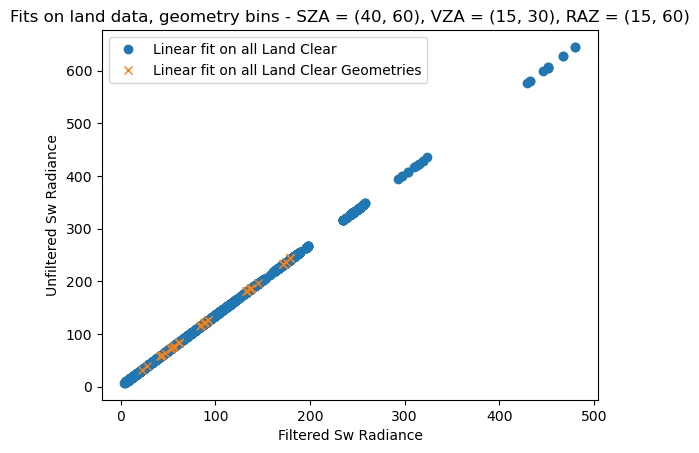

In [7]:
plt.plot(filt_sw, predicted, "o", label="Linear fit on all Land Clear")
plt.plot(filt_sw_bin, predicted_bin, "x", label="Linear fit on all Land Clear Geometries")
plt.title("Fits on land data, geometry bins - SZA = (40, 60), VZA = (15, 30), RAZ = (15, 60)")
plt.xlabel("Filtered Sw Radiance")
plt.ylabel("Unfiltered Sw Radiance")
plt.legend()


print("For all Land Clear data:")
print(f"r^2 Value: {r2_score(unfilt_sw, predicted)}")
print(f"Mean Squared Error: {mean_squared_error(unfilt_sw, predicted)}")
print("\nFor binned Land Clear data:")
print(f"r^2 Value: {r2_score(unfilt_sw_bin, predicted_bin)}")
print(f"Mean Squared Error: {mean_squared_error(unfilt_sw_bin, predicted_bin)}")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def compare_global_vs_bin_fit(df, scene="Land", sza_range=(45,60), vza_range=(15,30), raz_range=(15,60), degree=1):
    """
    Compare global linear/poly fit vs a single geometry-bin fit.
    Plots both fits together.

    Args:
        df: DataFrame with 'Scene','SZA','VZA','RAZ', SW filtered/unfiltered columns.
        scene: which Scene to filter to.
        *_range: tuple of (low, high) to select bin for SZA,VZA,RAZ.
        degree: polynomial degree (1=linear, 2=quadratic).
    """
    filt_col = "Shortwave Filtered Rads (Integrated)"
    unfilt_col = "Shortwave Unfiltered Rads (Integrated)"

    # ---- GLOBAL FIT ----
    land = df[df["Scene"] == scene]
    X_global = land[[filt_col]].to_numpy().reshape(-1, 1)  # just filtered radiance
    y_global = land[unfilt_col].to_numpy().reshape(-1, 1)

    poly = PolynomialFeatures(degree=degree)
    Xg_poly = poly.fit_transform(X_global)
    g_model = LinearRegression().fit(Xg_poly, y_global)

    # ---- BIN FIT ----
    # subset = land[
    #     land["SZA"].between(*sza_range) &
    #     land["VZA"].between(*vza_range) &
    #     land["RAZ"].between(*raz_range)
    # ]
    subset = land[(land["SZA"].between(40,60)) &
                  (land["VZA"].between(15,60)) &
                  (land["RAZ"].between(15,60))]

    X_bin = subset['Shortwave Filtered Rads (Integrated)'].to_numpy().reshape(-1, 1)
    y_bin = subset['Shortwave Unfiltered Rads (Integrated)'].to_numpy().reshape(-1, 1)

    Xb_poly = poly.fit_transform(X_bin)
    b_model = LinearRegression().fit(Xb_poly, y_bin)

    # Get R² and RMSE for both models
    g_pred = g_model.predict(Xg_poly)
    b_pred = b_model.predict(Xb_poly)

    # Print metrics and coefficients
    print("For all Land Clear data:")
    print(f"R² Value: {r2_score(y_global, g_pred)}")
    print(f"Root Mean Squared Error: {root_mean_squared_error(y_global, g_pred)}")
    print(f"coefficients: {g_model.coef_}, intercept: {g_model.intercept_}")
    # if degree == 1:
    #     print(f"Slope: {g_model.coef_[0][0]}")
    #     print(f"Intercept: {g_model.intercept_[0]}")
    #     print(f"Equation: y = {g_model.coef_[0][0]:.4f}x + {g_model.intercept_[0]}")
    # else:
    #     print("Polynomial coefficients (highest degree first):")
    #     for i, coef in enumerate(reversed(g_model.coef_[0][1:])):
    #         print(f"x^{degree-i}: {coef:.4f}")
    #     print(f"Intercept: {g_model.intercept_[0]}")

    print("\nFor binned Land Clear data:")
    print(f"R² Value: {r2_score(y_bin, b_pred)}")
    print(f"Root Mean Squared Error: {root_mean_squared_error(y_bin, b_pred)}")
    print(f"coefficients: {b_model.coef_}, intercept: {b_model.intercept_}")
    # if degree == 1:
    #     print(f"Slope: {b_model.coef_[0][0]:.4f}")
    #     print(f"Intercept: {b_model.intercept_[0]}")
    #     print(f"Equation: y = {b_model.coef_[0][0]}x + {b_model.intercept_[0]}")
    # else:
    #     print("Polynomial coefficients (highest degree first):")
    #     for i, coef in enumerate(reversed(b_model.coef_[0][1:])):
    #         print(f"x^{degree-i}: {coef}")
    #     print(f"Intercept: {b_model.intercept_[0]}")

    x_line = np.linspace(min(X_global.min(), X_bin.min()),
                         max(X_global.max(), X_bin.max()), 200).reshape(-1,1)
    x_line_poly = poly.transform(x_line)

    plt.figure(figsize=(7,4))
    # scatter the data
    plt.scatter(X_global, y_global, s=12, alpha=0.3, label="All Land data")
    idx_g = np.argsort(X_global.ravel())
    plt.plot(X_global[idx_g], g_model.predict(Xg_poly)[idx_g],
             color="green", lw=2, label=f"{scene} fit")

    plt.xlabel("Filtered SW Radiance")
    plt.ylabel("Unfiltered SW Radiance")
    plt.title(f"All Land Clear data")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,4))
    plt.scatter(X_bin, y_bin, s=25, alpha=0.7, label=f"{scene} bin data")
    # plt.scatter(X_global, y_global, s=12, alpha=0.3, label="All Land data")
    idx_b = np.argsort(X_bin.ravel())
    # plt.plot(X_global[idx_g], g_model.predict(Xg_poly)[idx_g],
    #          color="green", lw=2, label="All Land Clear fit")
    plt.plot(X_bin[idx_b], b_model.predict(Xb_poly)[idx_b],
             color="red", lw=2, label="Bin Land Clear fit")

    plt.xlabel("Filtered SW Radiance")
    plt.ylabel("Unfiltered SW Radiance")
    plt.xlim(0, 250)
    plt.ylim(0, 450)
    plt.title(f"Scene={scene}, Bin SZA={sza_range}, VZA={vza_range}, RAZ={raz_range}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # plot fits
    # change the global line to orange, bin line to, say, purple
    # plt.plot(X_global, g_model.predict(Xg_poly), color="orange", lw=2, label="Global fit")
    # plt.plot(X_bin, b_model.predict(Xb_poly), color="purple", lw=2, linestyle="--", label="Bin fit")
    # plt.plot(X_bin, X_bin, color="yellow", lw=2, linestyle="--", label="Linear reference")
    # plt.plot(X_bin, y_bin, color="red", lw=2, linestyle="--", label="Bin exact unfilt values")
    # plt.plot(X_global, y_global, color="green", lw=2, linestyle="--", label="All exact unfilt values")

    # plt.plot(x_line, g_model.predict(x_line_poly), color="orange", lw=2, label="All Land Clear fit")
    # plt.plot(x_line, b_model.predict(x_line_poly), color="yellow", lw=2, label="Bin Land Clear fit")

compare_global_vs_bin_fit(
    land_all,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1  # linear, or 2 for quadratic
)

NameError: name 'land_all' is not defined

In [11]:
land_all.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
       'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Scaled Shortwave Filtered',
       'Scaled Shortwave Unfiltered', 'Scaled Longwave Filtered',
       'Scaled Longwave Unfiltered'],
      dtype='object')

In [12]:
land_clear = land_all[land_all["Cloud"] == 0]
land_cloudy = land_all[land_all["Cloud"] == 1]

In [17]:
land_clear["SZA"].unique(), land_clear["VZA"].unique(), land_clear["RAZ"].unique()

(array([ 0.   ,  0.506,  0.405,  0.871,  0.697,  1.487,  1.19 , 10.   ,
         8.002, 41.4  , 41.906, 41.805, 40.995, 40.894, 42.271, 42.097,
        40.703, 40.529, 42.887, 42.59 , 40.21 , 39.913, 51.4  , 49.402,
        33.398, 31.4  , 60.   , 60.506, 60.405, 59.595, 59.494, 60.871,
        60.697, 59.303, 59.129, 61.487, 61.19 , 58.81 , 58.513, 70.   ,
        68.002, 51.998, 50.   , 75.   , 75.506, 75.405, 74.595, 74.494,
        75.871, 75.697, 74.303, 74.129, 76.487, 76.19 , 73.81 , 73.513,
        85.   , 83.002, 66.998, 65.   , 85.506, 85.405, 84.595, 84.494,
        85.871, 85.697, 84.303, 84.129, 86.487, 86.19 , 83.81 , 83.513,
        95.   , 93.002, 76.998]),
 array([ 0.     , 29.49001, 44.121  , 58.5    , 79.914  ]),
 array([  0. ,   7.5,  37.5,  90. , 142.5, 172.5]))

In [18]:
land_cloudy["SZA"].unique(), land_cloudy["VZA"].unique(), land_cloudy["RAZ"].unique()

(array([ 0.   ,  0.506,  0.405,  0.871,  0.697,  1.487,  1.19 , 10.   ,
         8.002, 41.4  , 41.906, 41.805, 40.995, 40.894, 42.271, 42.097,
        40.703, 40.529, 42.887, 42.59 , 40.21 , 39.913, 51.4  , 49.402,
        33.398, 31.4  , 60.   , 60.506, 60.405, 59.595, 59.494, 60.871,
        60.697, 59.303, 59.129, 61.487, 61.19 , 58.81 , 58.513, 70.   ,
        68.002, 51.998, 50.   , 75.   , 75.506, 75.405, 74.595, 74.494,
        75.871, 75.697, 74.303, 74.129, 76.487, 76.19 , 73.81 , 73.513,
        85.   , 83.002, 66.998, 65.   , 85.506, 85.405, 84.595, 84.494,
        85.871, 85.697, 84.303, 84.129, 86.487, 86.19 , 83.81 , 83.513,
        95.   , 93.002, 76.998]),
 array([ 0.     , 29.49001, 44.121  , 58.5    , 79.914  ]),
 array([  0. ,   7.5,  37.5,  90. , 142.5, 172.5]))

For all Land Clear data:
R² Value: 0.998586330255098
Root Mean Squared Error: 1.3378094390555044
coefficients: [[0.         1.33029349]], intercept: [1.8294728]

For binned Land Clear data:
R² Value: 0.9990947501499154
Root Mean Squared Error: 0.4377100010776031
coefficients: [[0.         1.29506035]], intercept: [3.24734218]


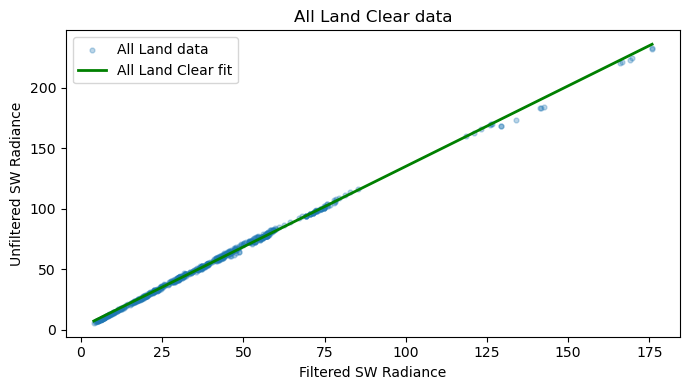

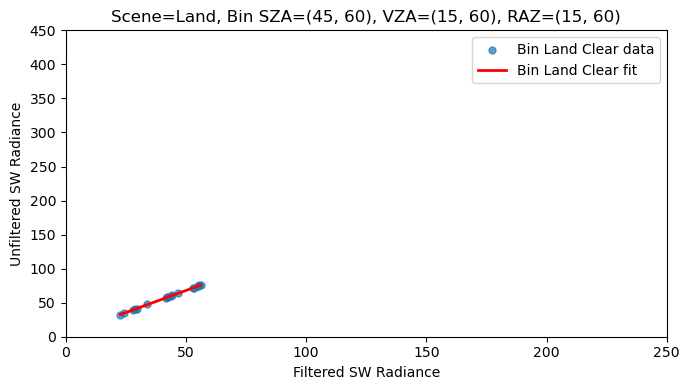

In [32]:
compare_global_vs_bin_fit(
    land_clear,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,60),
    raz_range=(15,60),
    degree=1  # linear, or 2 for quadratic
)

For all Land Clear data:
R² Value: 0.9988693062780992
Root Mean Squared Error: 2.9173050213773744
coefficients: [[0.         1.33852318]], intercept: [2.03532587]

For binned Land Clear data:
R² Value: 0.9999222890252646
Root Mean Squared Error: 0.5160969892563709
coefficients: [[0.         1.35211162]], intercept: [1.39338561]


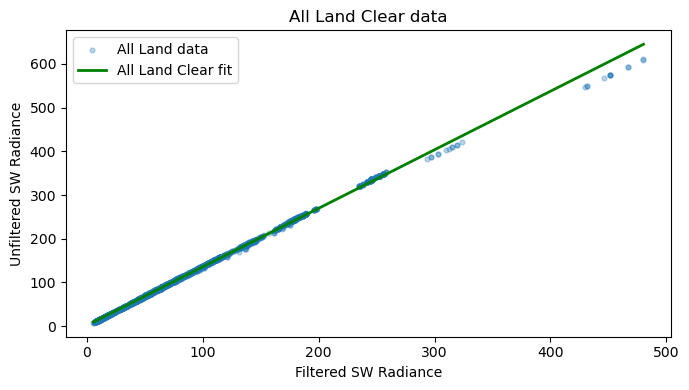

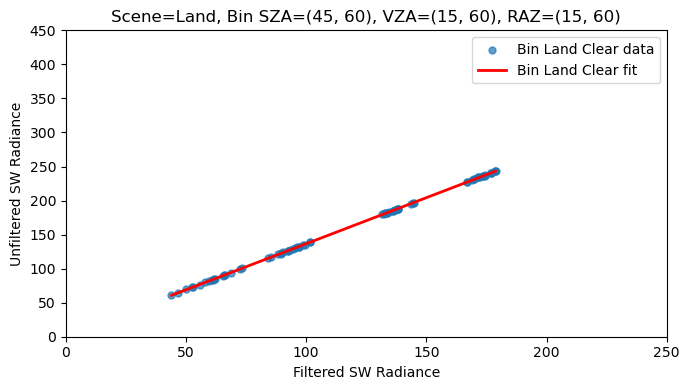

In [33]:
compare_global_vs_bin_fit(
    land_cloudy,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,60),
    raz_range=(15,60),
    degree=1  # linear, or 2 for quadratic
)

For all Land Clear data:
R² Value: 0.9974037887070017
Root Mean Squared Error: 1.68172578055097
coefficients: [[0.         1.31993824]], intercept: [2.94511157]

For binned Land Clear data:
R² Value: 0.9985851527184804
Root Mean Squared Error: 0.42043667590099615
coefficients: [[0.         1.36160246]], intercept: [2.45929505]


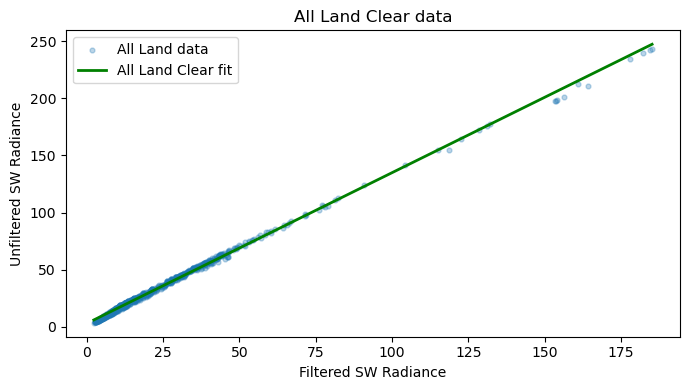

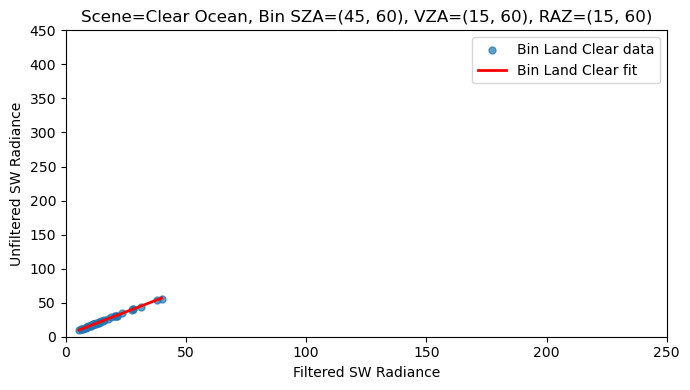

In [38]:
compare_global_vs_bin_fit(
    clear_dataset,
    scene="Clear Ocean",
    sza_range=(45,60),
    vza_range=(15,60),
    raz_range=(15,60),
    degree=1  # linear, or 2 for quadratic
)

For all Land Clear data:
R² Value: 0.9987406490881646
Root Mean Squared Error: 3.0100462045404197
coefficients: [[0.         1.34140077]], intercept: [2.21510996]

For binned Land Clear data:
R² Value: 0.9999141418818412
Root Mean Squared Error: 0.5031122795494272
coefficients: [[0.         1.35769652]], intercept: [1.24146224]


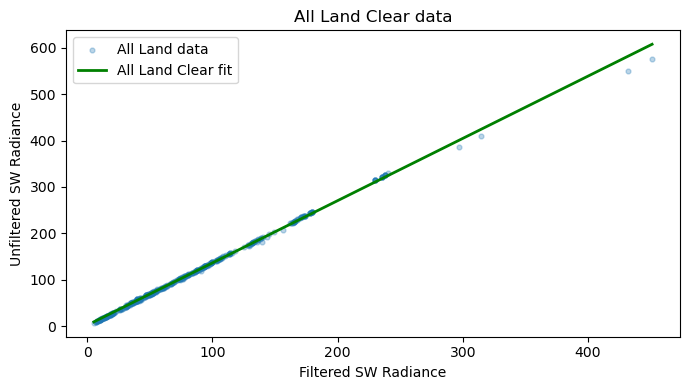

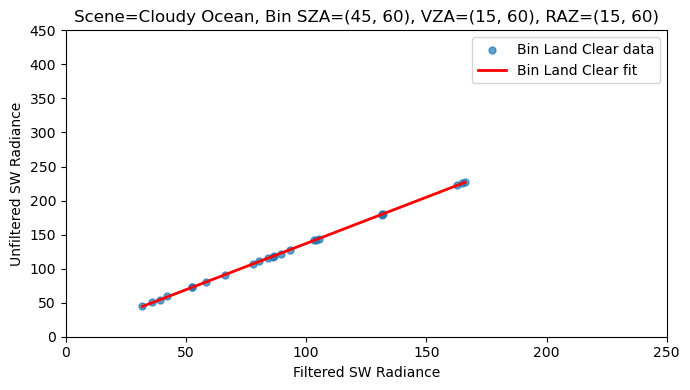

In [43]:
compare_global_vs_bin_fit(
    cloud_dataset,
    scene="Cloudy Ocean",
    sza_range=(45,60),
    vza_range=(15,60),
    raz_range=(15,60),
    degree=1  # linear, or 2 for quadratic
)